In [1]:

import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

experiment_id = "VISUALS"  # Use a fixed ID for reproducibility



# def plot_path_trajectories(sample_history, resample_history=None, divergence_points=None, hard_lim=None, experiment_id="VISUALS", name="gmm_path"):
#     import numpy as np
#     import matplotlib.pyplot as plt
#     from mpl_toolkits.mplot3d import Axes3D
#     import torch # Required for placeholder data
#     # ===================================================================
#     # 1. User-specified parameters & Setup
#     # ===================================================================
#     n_steps = len(sample_history)
#     n_samples = sample_history[0].shape[0]

#     # Define which snapshots to show as fractions of the total time. (which makes sense, since the total time ranges from 0 to 1)
#     snapshot_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.45, 0.8, 0.85, 0.9, 0.95, 1.0] #[0.0, 0.2, 0.4, 0.6, 0.8, 0.9999]
#     if divergence_points is not None:
#         # remove all points that are within the range of divergence points
#         dp_min, dp_max = divergence_points[0], divergence_points[-1]
#         snapshot_fractions = [s for s in snapshot_fractions if s < dp_min or s > dp_max]
#         # add divergence points to selected steps
#         snapshot_fractions = snapshot_fractions + divergence_points
            
#     selected_steps = [int(f * (n_steps - 1)) for f in snapshot_fractions]
    
#     if resample_history is not None:
#         selected_steps = selected_steps + resample_history
#     selected_steps = sorted(list(set(selected_steps)))  # Remove duplicates and sort

#     # Select a few random samples to visualize their full trajectory path.
#     n_trajectories = 20
#     trajectory_indices = np.random.choice(n_samples, size=n_trajectories, replace=False)


#     # ===================================================================
#     # 2. Plotting Setup
#     # ===================================================================
#     all_points = np.concatenate([sample_history[s].cpu().numpy() for s in selected_steps])
#     ymin, ymax = -5, 5
#     zmin, zmax = -5, 5
#     # if data min, max are outside [-5, 5], adjust the limits
#     ymin = min(ymin, all_points[:, 0].min())
#     ymax = max(ymax, all_points[:, 0].max())
#     zmin = min(zmin, all_points[:, 1].min())
#     zmax = max(zmax, all_points[:, 1].max())

#     if hard_lim is not None:
#         ymin, ymax, zmin, zmax = -hard_lim, hard_lim, -hard_lim, hard_lim

#     fig = plt.figure(figsize=(10,10), dpi=160)
#     ax = fig.add_subplot(111, projection='3d', computed_zorder = False)



#     # ===================================================================
#     # 3. Visualization (Painter's Algorithm for correct layering)
#     # ===================================================================

#     zorder_base = 0  # Base z-order for layering
#     for i in range(len(selected_steps)):
#         current_step = selected_steps[i]

#         # --- a) Plot FULLY CONNECTED trajectory segments LEADING TO the current snapshot ---
#         if i > 0:
#             prev_step = selected_steps[i-1]
#             for j in trajectory_indices:
#                 time_segment = np.arange(prev_step, current_step + 1)
#                 point_segment = np.array([sample_history[t][j].cpu().numpy() for t in time_segment])
#                 ax.plot(
#                     time_segment, 
#                     point_segment[:, 0], 
#                     point_segment[:, 1],
#                     color='black', linewidth=0.5, alpha=1, zorder = zorder_base
#                 )

#                 # --- c) Plot highlight dots on trajectories ---
#                 traj_points = np.array([sample_history[s][j].cpu().numpy() for s in selected_steps])
#                 ax.scatter(
#                     selected_steps, traj_points[:, 0], traj_points[:, 1],
#                     s=1, color='black', linewidths=1, alpha=0.5, depthshade=False, zorder=zorder_base
#                 )
#             zorder_base += 1  # Increment z-order for layering


#         # --- b) Plot the snapshot of all samples at the current step ---
#         pts = sample_history[current_step].cpu().numpy()
#         ax.scatter(
#             np.ones(n_samples) * current_step, pts[:, 0], pts[:, 1],
#             s=1, alpha=0.5, color='tab:blue', depthshade=False, zorder = zorder_base
#         )

#         if resample_history is not None:
#             if current_step in resample_history:
#                 # --- d) Plot resampled points with a different color ---
#                 zorder_base += 1  # Increment z-order for layering
#                 ax.scatter(
#                     np.ones(n_samples) * current_step, pts[:, 0], pts[:, 1],
#                     s=1, alpha=0.5, color='orange', depthshade=False, zorder = zorder_base
#                 )

#             zorder_base += 1  # Increment z-order for layering


#     # ===================================================================
#     # 4. Final Plot Styling
#     # ===================================================================
#     # --- Set axis limits and aspect ratio ---
#     ax.set_xlim(0, n_steps - 1)
#     ax.set_ylim(ymin, ymax)
#     ax.set_zlim(zmin, zmax)

#     # **CHANGE**: Adjusted aspect ratio to make the 2D planes appear wider.
#     ax.set_box_aspect((0.4 * len(selected_steps), 1, 1)) # (x, y, z)

#     # --- Floor lines and labels ---
#     y_floor = 0 #ax.get_ylim()[0] # Get bottom y-limit
#     z_floor = ax.get_zlim()[0] # Get bottom z-limit

#     # **CHANGE**: Reverted to horizontal floor axes like the original code.
#     y_tick_size = (ymax - ymin) * 0.5 # Proportional tick size
#     n_ground_lines = 10
#     x_positions = np.linspace(0, n_steps - 1, n_ground_lines)
#     for x_pos in x_positions:
#         ax.plot([x_pos, x_pos], [y_floor - y_tick_size, y_floor + y_tick_size], [z_floor, z_floor],
#                 color="black", linewidth=0.7, alpha=0.9)

#     # **CHANGE**: Reverted to the original, more descriptive labels.
#     label_offset = (ymax - ymin) * 0.3 # Proportional offset for labels
#     ax.text(-label_offset, y_floor - label_offset, z_floor - 0.3 * label_offset, r"$p_0$", fontsize=10, ha='center', va='top')
#     ax.text(n_steps - 1 - label_offset, y_floor - label_offset, z_floor - 0.3 * label_offset, r"$p_1$", fontsize=10, ha='center', va='top')

#     # --- Customize axis ticks and labels ---
#     ax.set_xlabel("time $t$")
#     ax.set_xticks([])

#     # Hide y and z axes for a cleaner look
#     ax.set_ylabel(""); ax.set_yticks([])
#     ax.set_zlabel(""); ax.set_zticks([])

#     # --- Remove panes and grid ---
#     ax.xaxis.pane.set_alpha(0)
#     ax.xaxis.pane.set_visible(False)
#     ax.xaxis.line.set_color((1,1,1,0))

#     ax.yaxis.pane.set_alpha(0)
#     ax.yaxis.pane.set_visible(False)
#     ax.yaxis.line.set_color((1,1,1,0))

#     ax.zaxis.pane.set_alpha(0)
#     ax.zaxis.pane.set_visible(False)
#     ax.zaxis.line.set_color((1,1,1,0))
#     ax.grid(False)


#     # --- Set camera angle ---
#     ax.view_init(elev=9, azim=-50)

#     plt.tight_layout()
#     plt.savefig(f"{experiment_id}/trajectory_plot_{name}.png", dpi=300)
#     plt.show()

# def plot_path_trajectories(sample_history, resample_history=None, divergence_points=None, hard_lim=None, experiment_id="VISUALS", name="gmm_path"):
#     import numpy as np
#     import matplotlib.pyplot as plt
#     from mpl_toolkits.mplot3d import Axes3D
#     import torch

#     # ===================================================================
#     # 1. User-specified parameters & Setup
#     # ===================================================================
#     n_steps = len(sample_history)
#     n_samples = sample_history[0].shape[0]
    
#     dp_min_step, dp_max_step = None, None
#     if divergence_points is not None:
#         dp_min, dp_max = divergence_points[0], divergence_points[-1]
#         dp_min_step = int(dp_min * (n_steps - 1))
#         dp_max_step = int(dp_max * (n_steps - 1))

#     snapshot_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.88, 0.96]
#     if divergence_points is not None:
#         snapshot_fractions = [s for s in snapshot_fractions if s < dp_min or s > dp_max]
#         snapshot_fractions.extend(divergence_points)
            
#     selected_steps = [int(f * (n_steps - 1)) for f in snapshot_fractions]
    
#     if resample_history is not None:
#         selected_steps.extend(resample_history)
#     selected_steps = sorted(list(set(selected_steps)))

#     n_trajectories = 20
#     trajectory_indices = np.random.choice(n_samples, size=n_trajectories, replace=False)

#     # ===================================================================
#     # 2. Plotting Setup
#     # ===================================================================
#     all_points = np.concatenate([sample_history[s].cpu().numpy() for s in selected_steps])
#     ymin, ymax = -5, 5
#     zmin, zmax = -5, 5
#     ymin = min(ymin, all_points[:, 0].min())
#     ymax = max(ymax, all_points[:, 0].max())
#     zmin = min(zmin, all_points[:, 1].min())
#     zmax = max(zmax, all_points[:, 1].max())

#     if hard_lim is not None:
#         ymin, ymax, zmin, zmax = -hard_lim, hard_lim, -hard_lim, hard_lim

#     fig = plt.figure(figsize=(10,10), dpi=160)
#     ax = fig.add_subplot(111, projection='3d', computed_zorder=False)

#     # ===================================================================
#     # 3. Visualization with Z-Ordering and Gap Handling
#     # ===================================================================
    
#     # **MODIFICATION**: Re-introduced the z-order counter
#     zorder_base = 0 

#     # Loop through each time slice to draw it layer by layer
#     for i in range(len(selected_steps)):
#         current_step = selected_steps[i]

#         # --- a) Plot trajectory segments LEADING TO the current snapshot ---
#         if i > 0:
#             prev_step = selected_steps[i-1]

#             # Check if the segment crosses the divergence gap. If so, skip it.
#             if divergence_points and prev_step <= dp_min_step and current_step >= dp_max_step:
#                 pass # This is the gap-crossing segment, do nothing
#             else:
#                 # Plot the valid segment with the current base z-order
#                 for j in trajectory_indices:
#                     time_segment = np.arange(prev_step, current_step + 1)
#                     point_segment = np.array([sample_history[t][j].cpu().numpy() for t in time_segment])
#                     ax.plot(
#                         time_segment, point_segment[:, 0], point_segment[:, 1],
#                         color='black', linewidth=0.5, alpha=1, zorder=zorder_base
#                     )
        
#         # --- b) Plot the snapshot of all samples ---
#         # Draw this on top of the lines that led to it
#         pts = sample_history[current_step].cpu().numpy()
#         ax.scatter(
#             np.ones(n_samples) * current_step, pts[:, 0], pts[:, 1],
#             s=1, alpha=0.5, color='tab:blue', depthshade=False, zorder=zorder_base + 1
#         )

#         # --- d) Plot resampled points with a different color ---
#         if resample_history and current_step in resample_history:
#             # Draw these on top of the regular snapshot points
#             ax.scatter(
#                 np.ones(n_samples) * current_step, pts[:, 0], pts[:, 1],
#                 s=1, alpha=0.5, color='orange', depthshade=False, zorder=zorder_base + 2
#             )
        
#         # **MODIFICATION**: Increment the base z-order for the next time slice
#         zorder_base += 3 # Increment by 3 to leave room for line, scatter, and resample


#     # --- c) Plot highlight dots LAST with the highest z-order to ensure they are on top ---
#     for j in trajectory_indices:
#         traj_points = np.array([sample_history[s][j].cpu().numpy() for s in selected_steps])
#         ax.scatter(
#             selected_steps, traj_points[:, 0], traj_points[:, 1],
#             s=1, color='black', linewidths=1, alpha=0.5, depthshade=False, zorder=zorder_base
#         )
    
#     # [The rest of your styling code remains unchanged...]
#     # ===================================================================
#     # 4. Final Plot Styling
#     # ===================================================================
#     ax.set_xlim(0, n_steps - 1)
#     ax.set_ylim(ymin, ymax)
#     ax.set_zlim(zmin, zmax)
#     ax.set_box_aspect((0.4 * len(selected_steps), 1, 1))
#     y_floor = 0
#     z_floor = ax.get_zlim()[0]
#     y_tick_size = (ymax - ymin) * 0.5
#     n_ground_lines = 10
#     x_positions = np.linspace(0, n_steps - 1, n_ground_lines)
#     for x_pos in x_positions:
#         ax.plot([x_pos, x_pos], [y_floor - y_tick_size, y_floor + y_tick_size], [z_floor, z_floor],
#                 color="black", linewidth=0.7, alpha=0.9)
#     label_offset = (ymax - ymin) * 0.3
#     ax.text(-label_offset, y_floor - label_offset, z_floor - 0.3 * label_offset, r"$p_0$", fontsize=10, ha='center', va='top')
#     ax.text(n_steps - 1 - label_offset, y_floor - label_offset, z_floor - 0.3 * label_offset, r"$p_1$", fontsize=10, ha='center', va='top')
#     ax.set_xlabel("time $t$")
#     ax.set_xticks([])
#     ax.set_ylabel(""); ax.set_yticks([])
#     ax.set_zlabel(""); ax.set_zticks([])
#     ax.xaxis.pane.set_alpha(0); ax.yaxis.pane.set_alpha(0); ax.zaxis.pane.set_alpha(0)
#     ax.grid(False)
#     ax.view_init(elev=9, azim=-50)
#     plt.tight_layout()
#     plt.savefig(f"{experiment_id}/trajectory_plot_{name}.png", dpi=300)
#     plt.show()

def plot_path_trajectories(sample_history, n_frame=4, resample_history=None, divergence_points=None, hard_lim=None, experiment_id="VISUALS", name="gmm_path", deg=-60, num_trajectory_points=20):
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import torch

    # ===================================================================
    # 1. User-specified parameters & Setup
    # ===================================================================
    n_steps = len(sample_history)
    n_samples = sample_history[0].shape[0]
    
    dp_min_step, dp_max_step = None, None
    if divergence_points is not None:
        dp_min, dp_max = divergence_points[0], divergence_points[-1]
        dp_min_step = int(dp_min * (n_steps - 1))
        dp_max_step = int(dp_max * (n_steps - 1))

    # uniformly space n_frame fractions between 0 and 1, excluding the divergence region
    snapshot_fractions = np.linspace(0, 1, n_frame).tolist()
    if divergence_points is not None:
        snapshot_fractions = [s for s in snapshot_fractions if s < dp_min or s > dp_max]
        snapshot_fractions.extend(divergence_points)
            
    selected_steps = [int(f * (n_steps - 1)) for f in snapshot_fractions]
    
    if resample_history is not None:
        selected_steps.extend(resample_history)
    selected_steps = sorted(list(set(selected_steps)))

    n_trajectories = num_trajectory_points
    trajectory_indices = np.random.choice(n_samples, size=n_trajectories, replace=False)

    # ===================================================================
    # 2. Plotting Setup
    # ===================================================================
    all_points = np.concatenate([sample_history[s].cpu().numpy() for s in selected_steps])
    ymin, ymax = -5, 5
    zmin, zmax = -5, 5
    ymin = min(ymin, all_points[:, 0].min())
    ymax = max(ymax, all_points[:, 0].max())
    zmin = min(zmin, all_points[:, 1].min())
    zmax = max(zmax, all_points[:, 1].max())

    if hard_lim is not None:
        ymin, ymax, zmin, zmax = -hard_lim, hard_lim, -hard_lim, hard_lim

    fig = plt.figure(figsize=(10,10), dpi=160)
    ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
    
    # ===================================================================
    # **MODIFICATION**: Add transparent planes at divergence points
    # ===================================================================
    if divergence_points is not None:
        # Create a grid in the Y-Z plane
        scale_factor = 2  # Scale factor to extend planes beyond data limits
        y_plane = np.linspace(scale_factor * ymin, scale_factor * ymax, 2)
        z_plane = np.linspace(scale_factor * zmin, scale_factor * zmax, 2)
        Y_plane, Z_plane = np.meshgrid(y_plane, z_plane)

        # Plot the first plane at dp_min_step
        X_plane1 = np.full_like(Y_plane, dp_min_step)
        ax.plot_surface(X_plane1, Y_plane, Z_plane, color='orange', alpha=0.2, rstride=1, cstride=1, linewidth=0)

        # Plot the second plane at dp_max_step
        X_plane2 = np.full_like(Y_plane, dp_max_step)
        ax.plot_surface(X_plane2, Y_plane, Z_plane, color='green', alpha=0.2, rstride=1, cstride=1, linewidth=0)
    # ===================================================================


    # ===================================================================
    # 3. Visualization with Z-Ordering and Gap Handling
    # ===================================================================
    
    zorder_base = 0 

    for i in range(len(selected_steps)):
        current_step = selected_steps[i]

        if i > 0:
            prev_step = selected_steps[i-1]
            if divergence_points and prev_step <= dp_min_step and current_step >= dp_max_step:
                pass 
            else:
                for j in trajectory_indices:
                    time_segment = np.arange(prev_step, current_step + 1)
                    point_segment = np.array([sample_history[t][j].cpu().numpy() for t in time_segment])
                    ax.plot(
                        time_segment, point_segment[:, 0], point_segment[:, 1],
                        color='black', linewidth=0.5, alpha=1, zorder=zorder_base
                    )
        
        pts = sample_history[current_step].cpu().numpy()
        ax.scatter(
            np.ones(n_samples) * current_step, pts[:, 0], pts[:, 1],
            s=1, alpha=0.5, color='tab:blue', depthshade=False, zorder=zorder_base + 1
        )

        if resample_history and current_step in resample_history:
            ax.scatter(
                np.ones(n_samples) * current_step, pts[:, 0], pts[:, 1],
                s=1, alpha=0.5, color='orange', depthshade=False, zorder=zorder_base + 2
            )
        
        zorder_base += 3

    for j in trajectory_indices:
        traj_points = np.array([sample_history[s][j].cpu().numpy() for s in selected_steps])
        ax.scatter(
            selected_steps, traj_points[:, 0], traj_points[:, 1],
            s=1, color='black', linewidths=1, alpha=0.5, depthshade=False, zorder=zorder_base
        )
    
    # [The rest of your styling code remains unchanged...]
    # ===================================================================
    # 4. Final Plot Styling
    # ===================================================================
    ax.set_xlim(0, n_steps - 1)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)
    ax.set_box_aspect((0.4 * len(selected_steps), 1, 1))
    y_floor = 0
    z_floor = ax.get_zlim()[0]
    y_tick_size = (ymax - ymin) * 0.5
    n_ground_lines = 10
    x_positions = np.linspace(0, n_steps - 1, n_ground_lines)
    for x_pos in x_positions:
        ax.plot([x_pos, x_pos], [y_floor - y_tick_size, y_floor + y_tick_size], [z_floor, z_floor],
                color="black", linewidth=0.7, alpha=0.9)
    label_offset = (ymax - ymin) * 0.3
    ax.text(-label_offset, y_floor - label_offset, z_floor - 0.3 * label_offset, r"$p_0$", fontsize=10, ha='center', va='top')
    ax.text(n_steps - 1 - label_offset, y_floor - label_offset, z_floor - 0.3 * label_offset, r"$p_1$", fontsize=10, ha='center', va='top')
    ax.set_xlabel("time $t$")
    ax.set_xticks([])
    ax.set_ylabel(""); ax.set_yticks([])
    ax.set_zlabel(""); ax.set_zticks([])
    ax.xaxis.pane.set_alpha(0); ax.yaxis.pane.set_alpha(0); ax.zaxis.pane.set_alpha(0)
    ax.grid(False)
    # make all axis colors white
    ax.xaxis.line.set_color((1,1,1,0))
    # ax.yaxis.line.set_color((1,1,1,0))
    ax.zaxis.line.set_color((1,1,1,0))
    ax.view_init(elev=9, azim=deg)
    plt.tight_layout()
    plt.savefig(f"{experiment_id}/trajectory_plot_{name}.png", dpi=300)
    plt.show()

device → cuda


/tmp/ipykernel_348989/1563727213.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha_1 = lambda t : torch.tensor(1-t)
/tmp/ipykernel_348989/1563727213.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha_2 = lambda t : torch.tensor(1-t)
/tmp/ipykernel_348989/1563727213.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_3 = lambda t : torch.tensor(-1 * (1-2*t)**2)
/tmp/ipykernel_348989/1563727213.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.deta

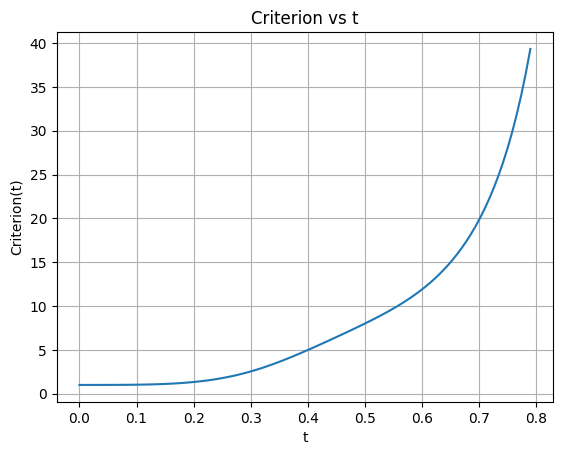

In [43]:
alpha_1 = lambda t : torch.tensor(1-t)
alpha_2 = lambda t : torch.tensor(1-t)
alpha_3 = lambda t : torch.tensor((1-t) * (t + (1-2*t)**2))
gamma_1 = lambda t : torch.tensor(1)
gamma_2 = lambda t : torch.tensor(1)
gamma_3 = lambda t : torch.tensor(-1 * (1-2*t)**2)

alpha_list = [alpha_1, alpha_2, alpha_3]
gamma_list = [gamma_1, gamma_2, gamma_3]

Criterion = lambda t: sum([ gamma_list[i](t) / (alpha_list[i](t))**2 for i in range(len(alpha_list)) ])

# plot Criterion for t in [0.0:0.01:0.99]
t = torch.linspace(0.0, 0.790, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
# plt.yscale('log')
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

# Checker Example

Models loaded.


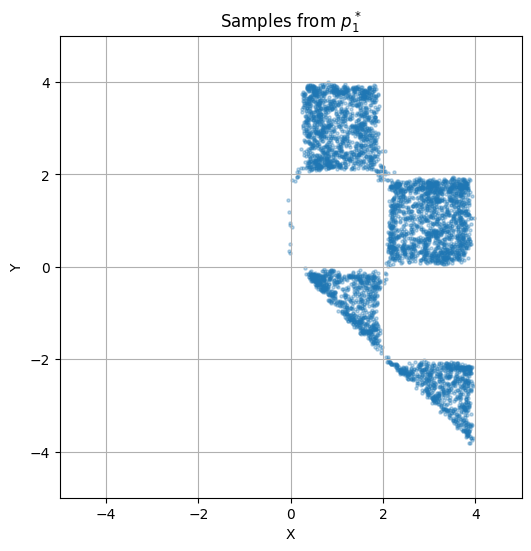

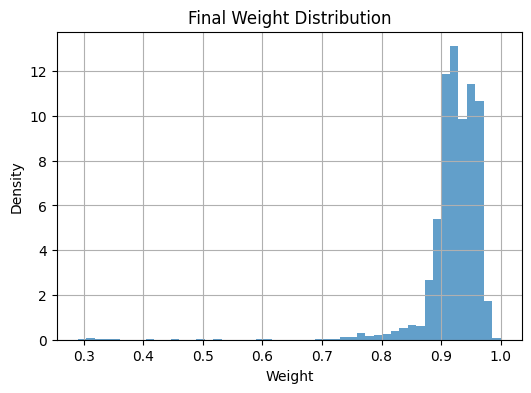

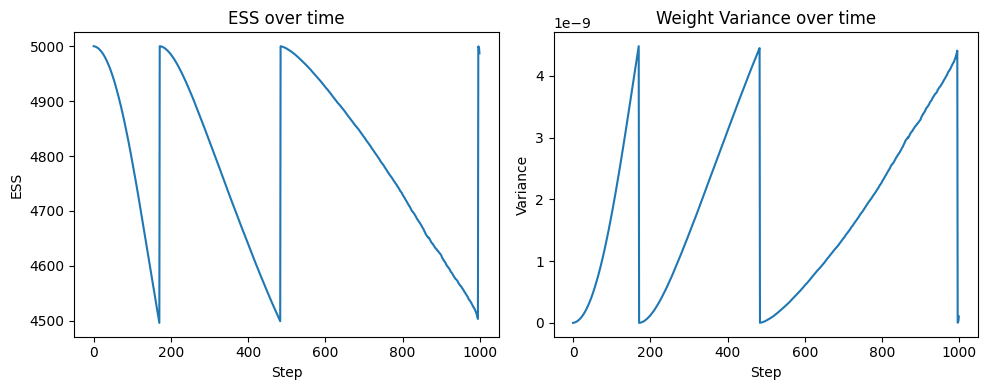

In [10]:
# Load all the models
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"models/u_model1_X_given_A.pth")); u_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"models/u_model2_XY_given_B.pth")); u_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"models/u_model3_X.pth")); u_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return (v1_fn(x, t, A) * t - x) / (1 - t + 1e-8)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return (v2_fn(x, t) * t - x) / (1 - t + 1e-8)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return (v3_fn(z, t, B) * t - z) / (1 - t + 1e-8)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")

bs = 5000
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    #lambda z, t: torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.9,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/checker_hcg_samples")

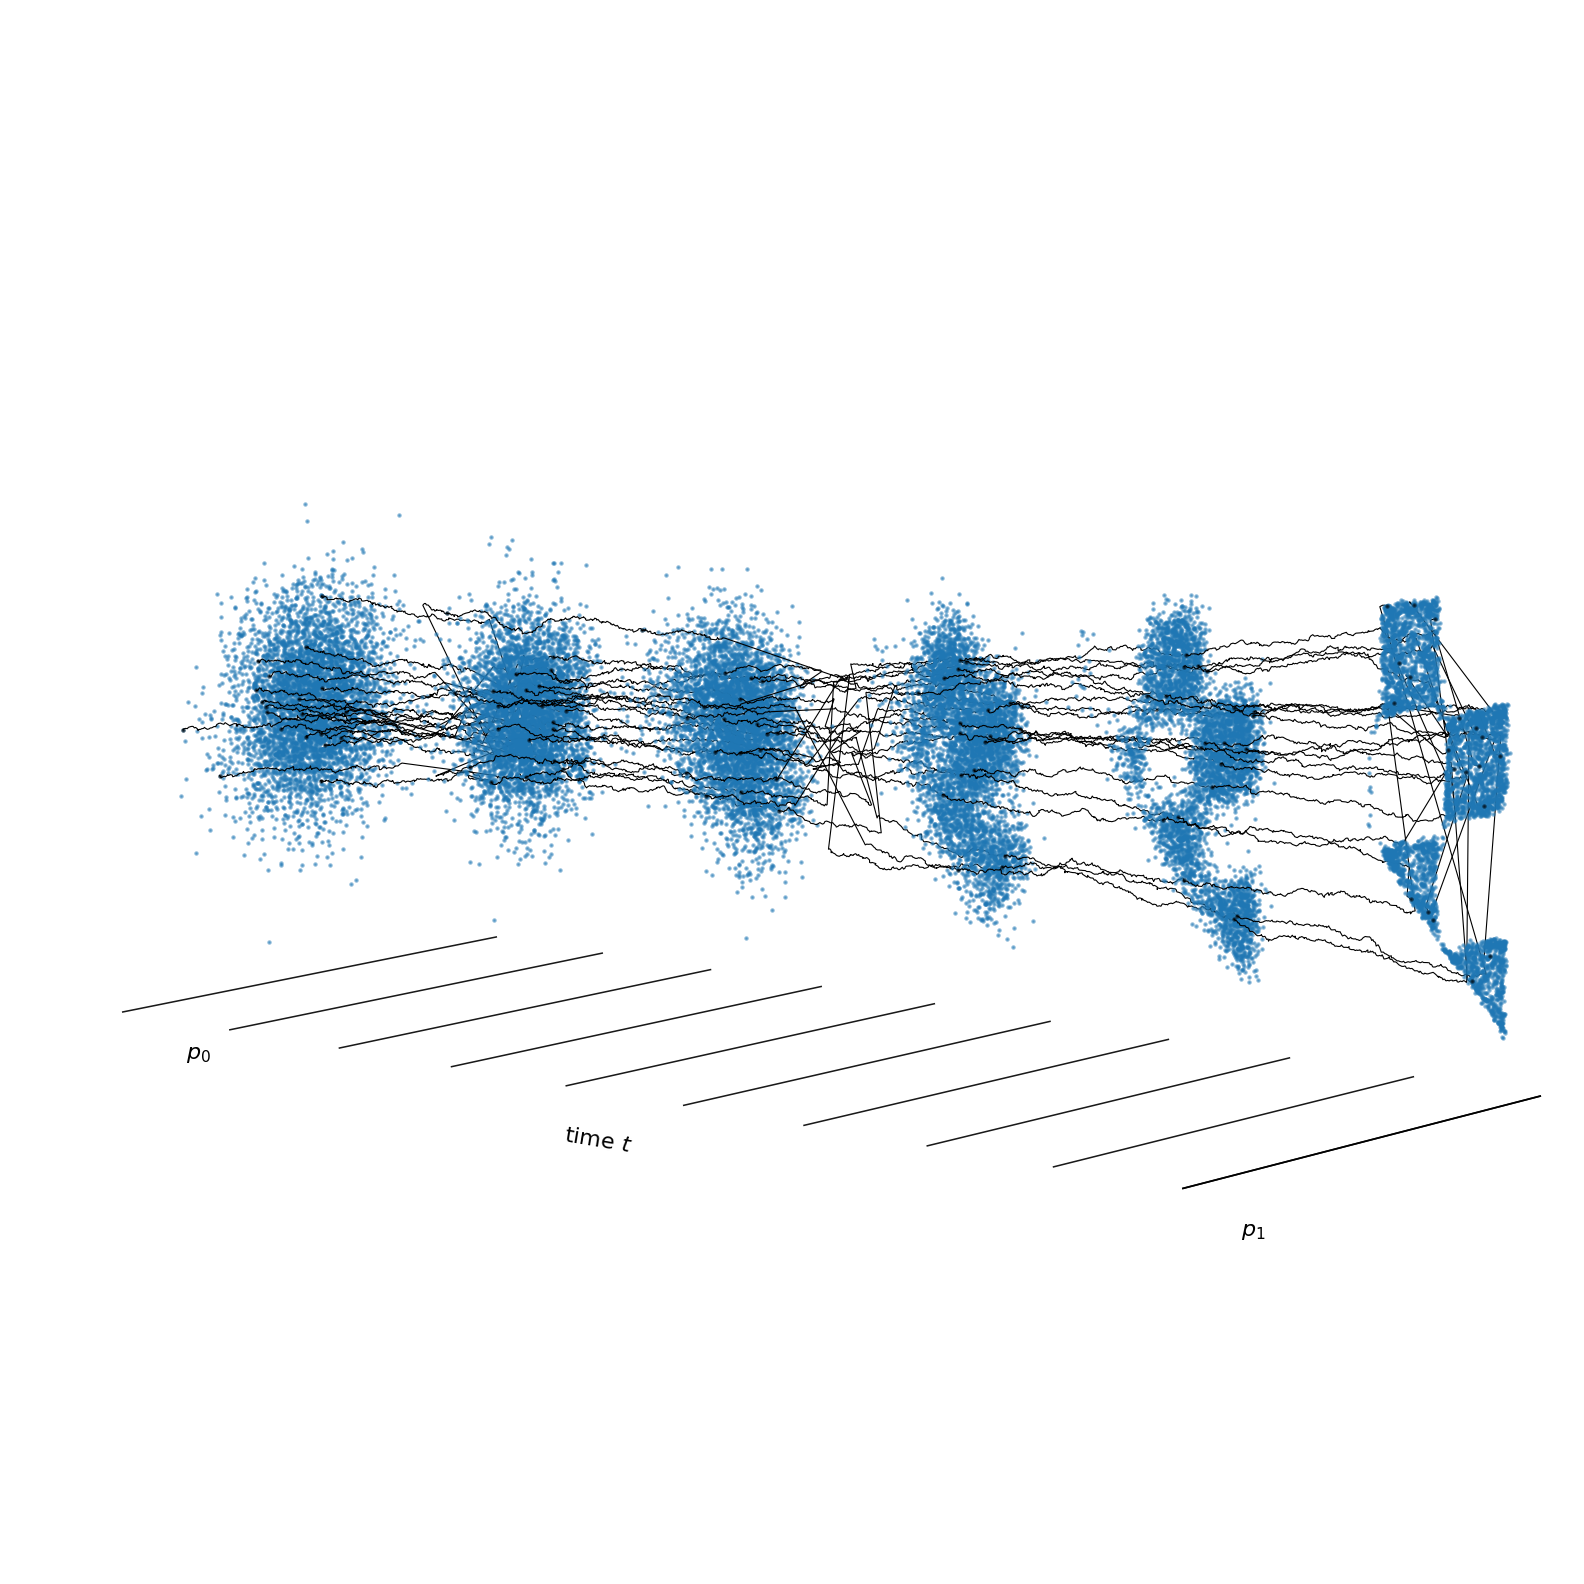

In [14]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name="checker_path", deg=-50)

# Counter Example: Gaussian Mixture Model Ratio Blow-Up

## We can simplify the GMM example for convenience:
Let $p_t$ denote the path from $p_0=\mathcal{N}(0,\sigma_0^2I)$ to $p_1=\mathcal{N}(0,\sigma_1^2I)$ via $X_t = (1-t)X_0 + tX_1$. 

Then, the intermediate densities will be $p_t = \mathcal{N}(0, \left((1-t)^2\sigma_0^2 + t^2 \sigma_1^2\right)I)$

The score function is simply
$$
\nabla \log p_t (X) = -\frac{1}{(1-t)^2\sigma_0^2 + t^2 \sigma_1^2} X
$$

## Deriving the SDE from the Path

For a general SDE of the form $dX_t = f(t,X_t)dt + g(t)dW_t$, the evolution of its variance $\sigma_t^2$ for a zero-mean Guassian process is governed by the Fokker-Planck equation:
$$
\frac{d\sigma_t^2}{dt} = 2\mu(t)\sigma_t^2 + g(t)^2
$$
where we assumed linear drift of the form $f(t,X_t) = \mu(t)X_t$. For this specific path, we have
$$
\mu(t) = \frac{-2(1-t)\sigma_0^2 + 2t\sigma_1^2 - g(t)^2}{2((1-t)^2\sigma_0^2 + t^2\sigma_1^2)}
$$
and the full drift is then $f(t,X_t) = \mu(t)X_t$.

As a result, we have
$$
dX_t = \frac{-2(1-t)\sigma_0^2 + 2t\sigma_1^2 - g(t)^2}{2((1-t)^2\sigma_0^2 + t^2\sigma_1^2)} X_tdt + g(t)dW_t
$$

Potential divergence points at: []
Effective variance at 1.0: 1.0


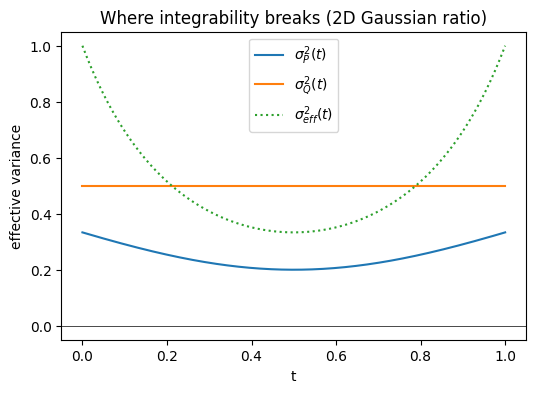

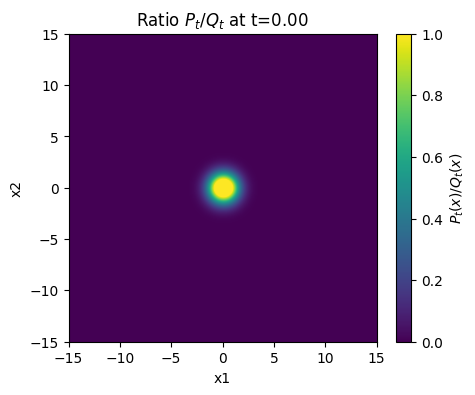

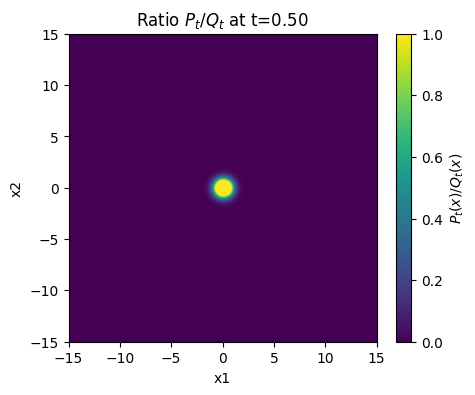

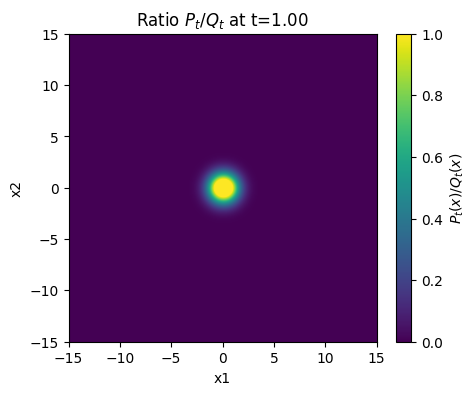

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# def sigma_p1(t): return (1-t)**2 + 0.5*t**2
# def sigma_p2(t): return (1-t)**2 + 7*t**2
# def sigma_q1(t): return 1.5*(1-t)**2 + t**2
# def sigma_q2(t): return 1.5*(1-t)**2 + t**2

def sigma_p1(t): return 0.5*(1-t)**2 + 0.5*t**2
def sigma_p2(t): return 1
def sigma_q1(t): return 1
def sigma_q2(t): return 1
def sigma_eff(var1, var2):
    return 1.0 / (1/var1 + 1/var2)

def sigma_P(t):
    return sigma_eff(sigma_p1(t), sigma_p2(t))

def sigma_Q(t):
    return sigma_eff(sigma_q1(t), sigma_q2(t))

def eff_var(ts, var1, var2):
    # var1, var2 are numpy arrays
    #return ts, 1.0 / (1/var1 - 1/var2) for indices where var1 < var2
    indices = np.where(var1 < var2)[0]
    # print("Indices where var1 < var2:", indices)
    eff_ts = ts[indices]
    eff_vars = 1.0 / (1/var1[indices] - 1/var2[indices])
    return eff_ts, eff_vars


# Find break points where integrability flips
ts = np.linspace(0,1,500)
sigP = np.array([sigma_P(t) for t in ts])
sigQ = np.array([sigma_Q(t) for t in ts])
diff = sigP - sigQ
sign_changes = ts[np.where(np.diff(np.sign(diff)))[0]]
eff_ts, eff_vars = eff_var(ts, sigP, sigQ)
# print(f"eff_ts: {len(eff_ts)}, eff_vars: {len(eff_vars)}")

print("Potential divergence points at:", sign_changes)
# I want the effective variance at t = 0.8
# t_eff = sign_changes[-1] + 0.03
t_eff = 1.0
i_eff = (np.abs(eff_ts - t_eff)).argmin()
print(f"Effective variance at {t_eff}: {eff_vars[i_eff]}")

# Plot variances
plt.figure(figsize=(6,4))
plt.plot(ts, sigP, label=r"$\sigma_P^2(t)$")
plt.plot(ts, sigQ, label=r"$\sigma_Q^2(t)$")
plt.plot(eff_ts, eff_vars, label=r"$\sigma_{eff}^2(t)$", ls=':')
plt.axhline(0, color='black', lw=0.5)
for sc in sign_changes:
    plt.axvline(sc, color='red', ls='--', label="break point")
plt.legend()
plt.xlabel("t")
plt.ylabel("effective variance")
# plt.ylim(-1, 110)
plt.title("Where integrability breaks (2D Gaussian ratio)")
plt.show()


scale = 15
x_min, x_max, y_min, y_max = scale * -1, scale * 1, scale * -1, scale * 1

# Grid for visualization
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
pos = np.dstack((xx,yy))

def ratio_density(t):
    covP = sigma_P(t) * np.eye(2)
    covQ = sigma_Q(t) * np.eye(2)
    p = multivariate_normal([0,0], covP).pdf(pos)
    q = multivariate_normal([0,0], covQ).pdf(pos)
    ratio = p / q
    return ratio #np.clip(ratio, 0, 1e18)  # cap at 1e18 for visualization

# Fixed colormap range
vmin, vmax = 0, 1

for t in [0.0, 0.5, 1.0]:
    ratio = ratio_density(t)
    plt.figure(figsize=(5,4))
    cmap = plt.cm.viridis
    im = plt.imshow(ratio, extent=(x_min,x_max,y_min,y_max), origin="lower", 
                    cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, label=r"$P_t(x)/Q_t(x)$")
    plt.title(f"Ratio $P_t/Q_t$ at t={t:.2f}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()



Simulating SDE: 100%|██████████| 1000/1000 [00:00<00:00, 7093.06it/s]


Simulation finished. `sample_history` contains 1001 timesteps.


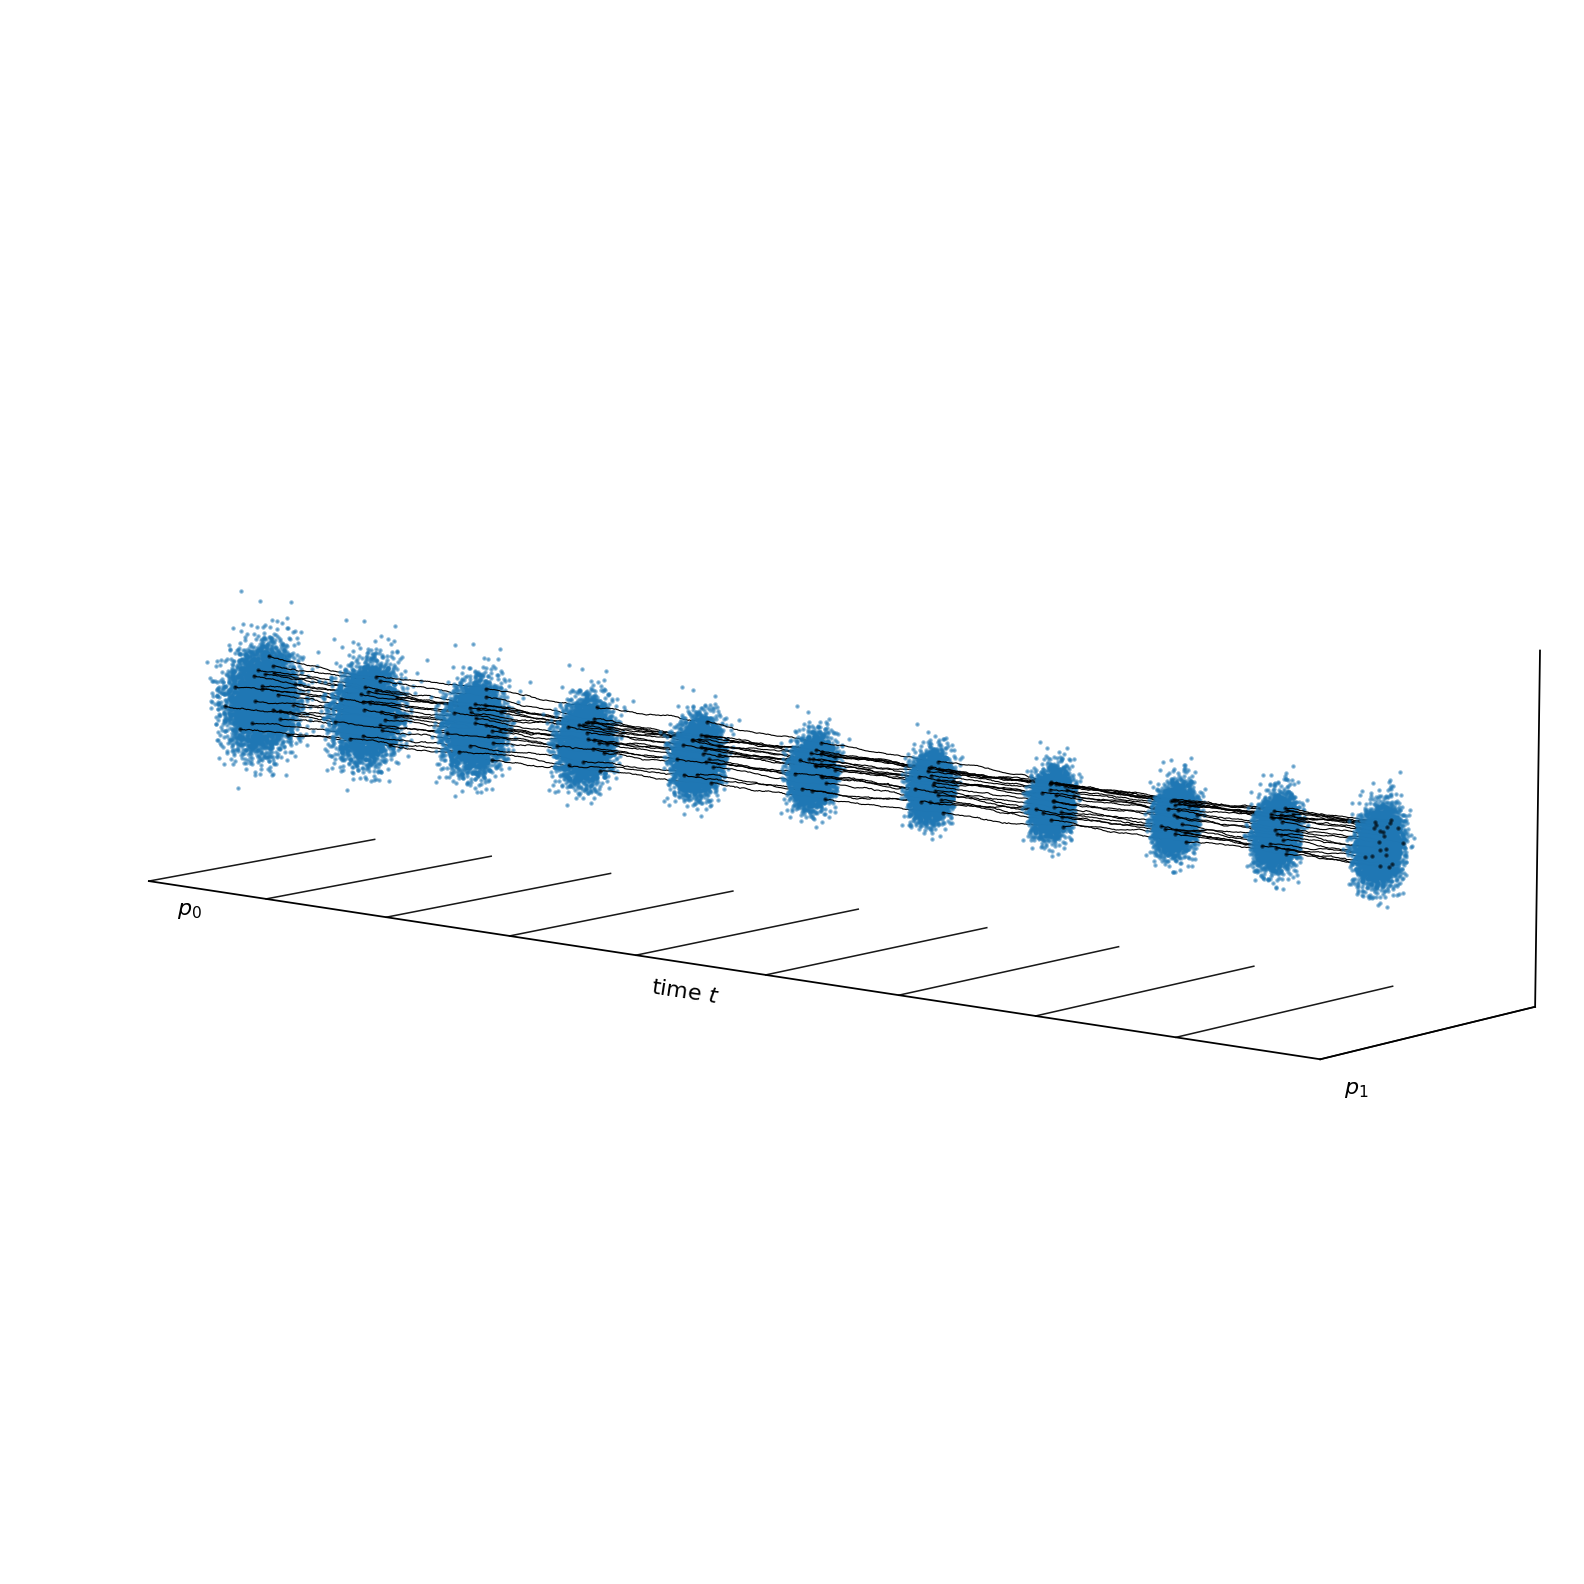

In [183]:
# simulate SDE dX_t = \frac{-2(1-t)\sigma_0^2 + 2t\sigma_1^2 - g(t)^2}{2((1-t)^2\sigma_0^2 + t^2\sigma_1^2)} X_tdt + g(t)dW_t with g(t) = 0.5
import torch
import numpy as np
import tqdm # For a progress bar

# --- 1. Simulation Parameters ---
sigma_0 = 1.5
sigma_1 = 1

n_samples = 5000   # Number of parallel sample paths to simulate
dim = 2            # Dimension of the samples (e.g., 2 for 2D points)
n_timesteps = 1000 # Number of discretization steps
T = 1.0            # Total simulation time
dt = T / n_timesteps # Time step size

# For any linear path between two isotropic gaussians, the score and velocity functions are:
def v_fn(x, t, sigma_0, sigma_1):
    return (-2 * (1-t) * sigma_0**2 + 2 * t * sigma_1 **2) * x / ( 2 * ((1-t)**2 * sigma_0**2 + t**2 * sigma_1**2) )
def s_fn(x, t, sigma_0, sigma_1):
    return - x / ((1-t)**2 * sigma_0**2 + t**2 * sigma_1**2)


# --- 2. SDE Coefficients ---
def g_fn(t):
    return 0.5


# --- 3. SDE Simulation ---

# Initial samples from p_0 = N(0, sigma_0^2 * I)
# We'll keep the simulation on the CPU, but you can move to 'cuda' for speed
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X_t = torch.randn(n_samples, dim, device=device) * sigma_0

# The list to store the history of distributions at each timestep
sample_history = [X_t.clone()]

# The main simulation loop using the Euler-Maruyama method
for i in tqdm.tqdm(range(n_timesteps), desc="Simulating SDE"):
    t = i * dt
    g_t = g_fn(t)
    
    # Calculate the drift term: f(X_t, t) * dt
    # drift_coeff = get_drift_coeff(t, sigma_0, sigma_1)
    # drift = drift_coeff * X_t * dt
    v_value = v_fn(X_t, t, sigma_0, sigma_1) + 0.5 * g_t**2 * s_fn(X_t, t, sigma_0, sigma_1)
    drift = v_value * dt

    # Calculate the diffusion term: g(t) * dW_t
    # dW_t is modeled as sqrt(dt) * N(0, I)
    random_noise = torch.randn_like(X_t)
    diffusion = g_t * np.sqrt(dt) * random_noise
    
    # Update the state
    X_t = X_t + drift + diffusion
    
    # Store the result for this timestep
    sample_history.append(X_t.clone())

print(f"Simulation finished. `sample_history` contains {len(sample_history)} timesteps.")
plot_path_trajectories(sample_history, resample_history=None, hard_lim=10, experiment_id=experiment_id, name="gaussian_path_4")

In [9]:
def v1_fn(x, t): return v_fn(x, t, 1, 0.5)
def s1_fn(x, t): return s_fn(x, t, 1, 0.5)
def v2_fn(x, t): return v_fn(x, t, 1, 7)
def s2_fn(x, t): return s_fn(x, t, 1, 7)
def v3_fn(z, t): return v_fn(z, t, 1.5, 1)
def s3_fn(z, t): return s_fn(z, t, 1.5, 1)
def v4_fn(z, t): return v_fn(z, t, 1.5, 1)
def s4_fn(z, t): return s_fn(z, t, 1.5, 1)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")

bs = 5000
x0 = torch.sqrt(torch.tensor(1.5)) * torch.randn(bs, 2).to("cuda")  # (X, Y) sample
x_0_8 = torch.sqrt(torch.tensor(13.216)) * torch.randn(bs, 2).to("cuda")  # (X, Y) sample
x_0_65 = torch.sqrt(torch.tensor(39.95)) * torch.randn(bs, 2).to("cuda")  # (X, Y) sample


samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[2, 2, 2, 2],
    v_fn_list=[
        v1_fn, v2_fn, v3_fn, v4_fn
    ],
    s_fn_list=[
        s1_fn, s2_fn, s3_fn, s4_fn
    ],
    gamma_list=[1, 1, -1, -1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z,            # identity for Z
        lambda z: z,            # identity for Z
        lambda z: z,            # identity for Z
        lambda z: z             # identity for Z
    ],
    emb_list=[
        lambda z: z,            # identity for Z
        lambda z: z,            # identity for Z
        lambda z: z,            # identity for Z
        lambda z: z             # identity for Z
    ],
    sigma_fn=sigma_fn,
    v_star= lambda z, t: v1_fn(z, t) + v2_fn(z, t) - v3_fn(z, t) - v4_fn(z, t),
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=False,
    ess_threshold=0.3,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/blowup_samples")

samples_tail, logw_final_tail, logw_history_tail, sample_history_tail, resample_history_tail = simulate_hcg_generalized(
    x0=x_0_65, 
    dim_list=[2, 2, 2, 2],
    v_fn_list=[
        v1_fn, v2_fn, v3_fn, v4_fn
    ],
    s_fn_list=[
        s1_fn, s2_fn, s3_fn, s4_fn
    ],
    gamma_list=[1, 1, -1, -1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z,            # identity for Z
        lambda z: z,            # identity for Z
        lambda z: z,            # identity for Z
        lambda z: z             # identity for Z
    ],
    emb_list=[
        lambda z: z,            # identity for Z
        lambda z: z,            # identity for Z
        lambda z: z,            # identity for Z
        lambda z: z             # identity for Z
    ],
    sigma_fn=sigma_fn,
    v_star= lambda z, t: - 5 * v3_fn(z, t),
    t0=0.65, t1=1.0, n_steps=350,
    device="cuda",
    resample=False,
    ess_threshold=0.3,
    print_resample_history=True
)
samples_tail = samples_tail.cpu().numpy()
plot_diagnostics(samples_tail, logw_final_tail, logw_history_tail, save_name=f"{experiment_id}/blowup_samples_tail")

Models loaded.


NameError: name 'v_fn' is not defined

In [204]:
# Compute the variance for the final samples
print("Variance of initial samples (GT = 1.5):\t", np.var(sample_history[0].cpu().numpy(), axis=0))
print("Variance of final samples (GT = 7):\t", np.var(sample_history[-1].cpu().numpy(), axis=0))

print("Intermediate run: t=0.8 to t=1.0")
print("Variance of initial samples (GT = 39.95):\t", np.var(sample_history_tail[0].cpu().numpy(), axis=0))
print("Variance of final samples (GT = 7):\t", np.var(sample_history_tail[-1].cpu().numpy(), axis=0))

Variance of initial samples (GT = 1.5):	 [1.5037601 1.50368  ]
Variance of final samples (GT = 7):	 [69.51495 69.8445 ]
Intermediate run: t=0.8 to t=1.0
Variance of initial samples (GT = 39.95):	 [39.90702 39.02439]
Variance of final samples (GT = 7):	 [5.5202346 5.405502 ]


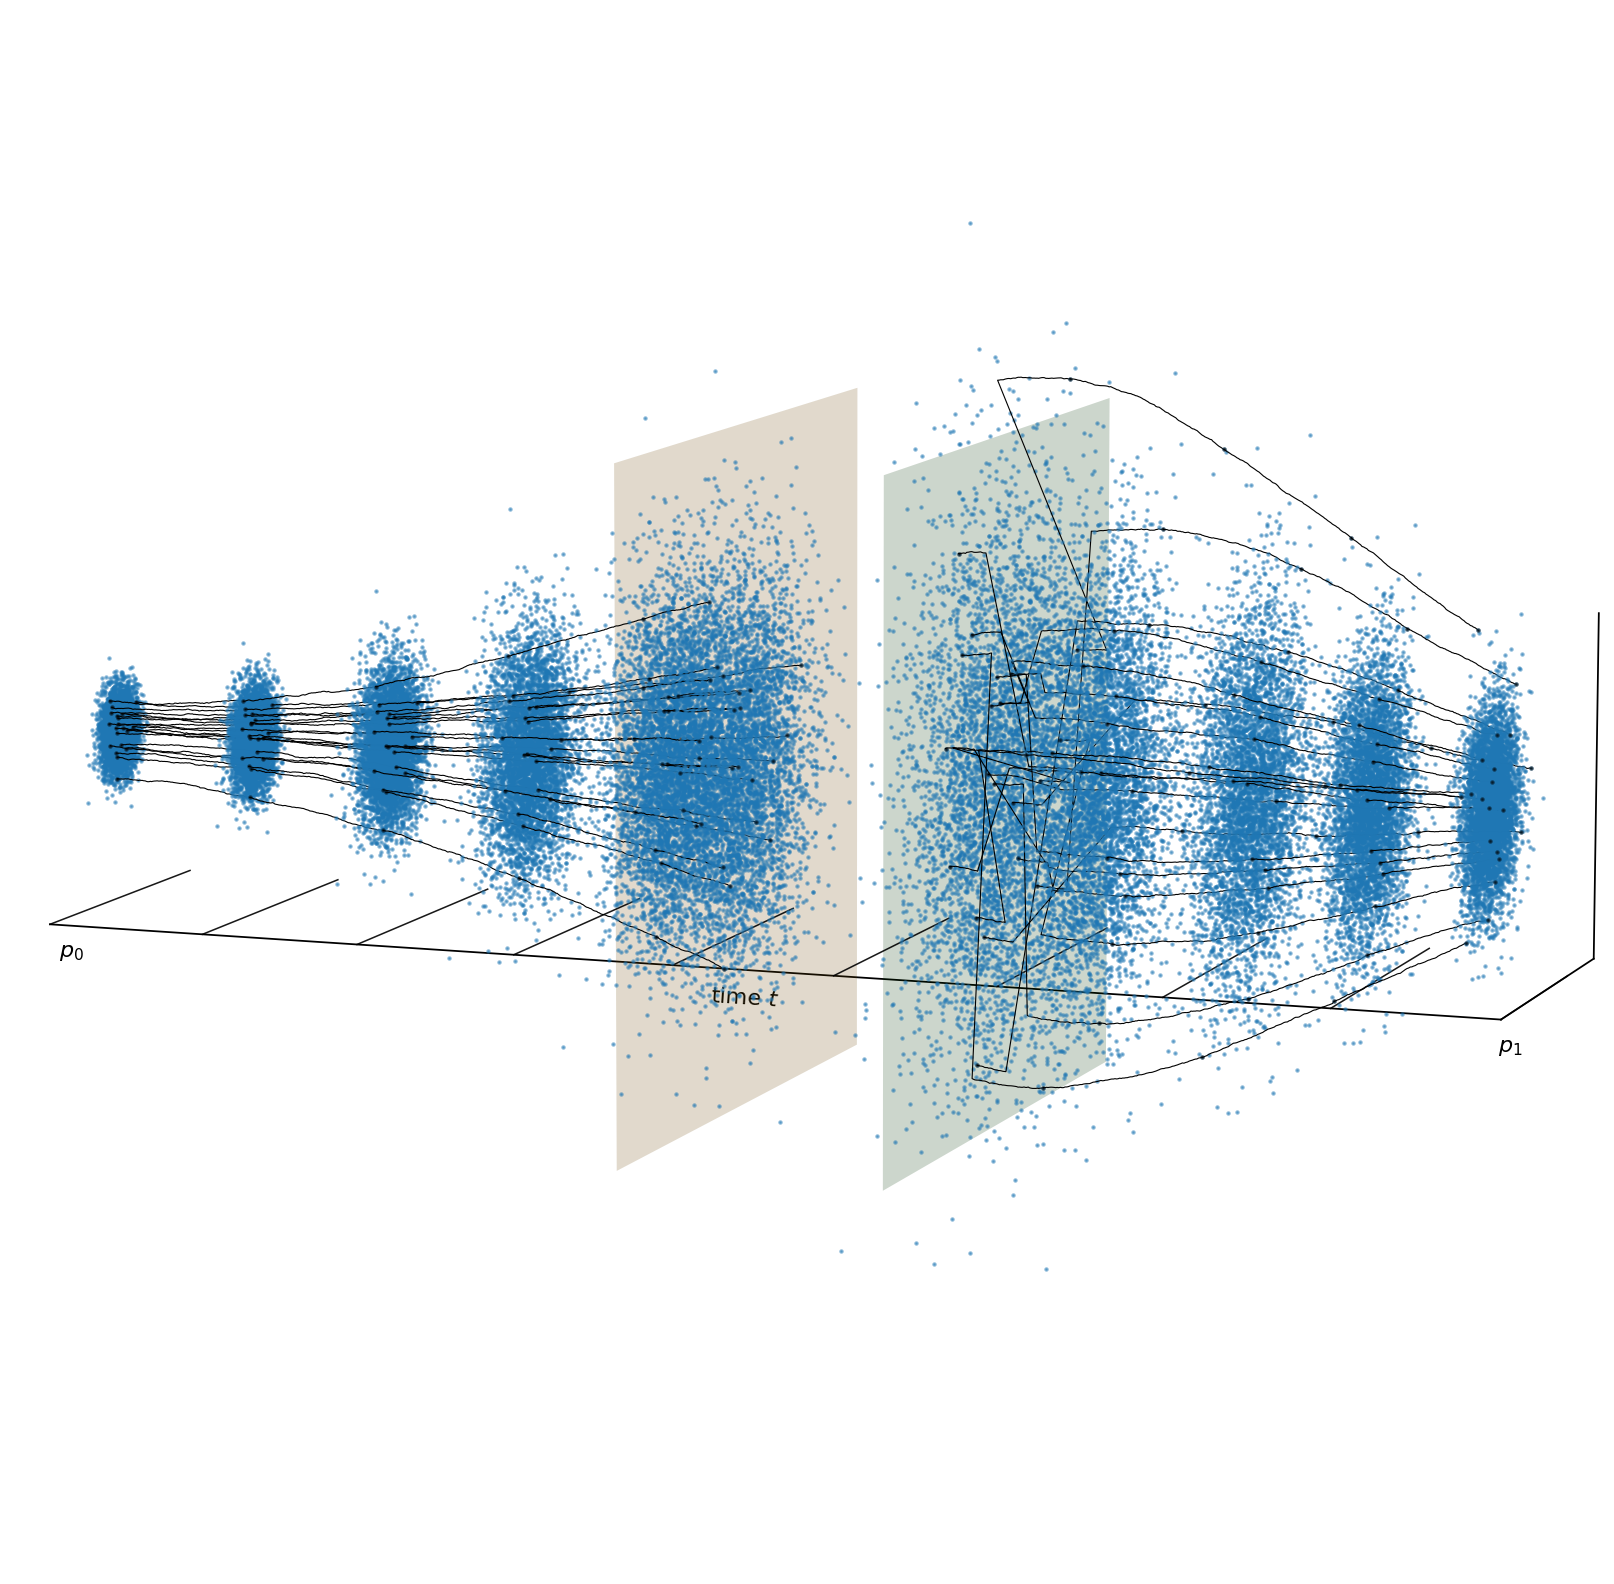

In [233]:
# Replace the final tail of sample_history with the tail run
sample_history = sample_history[:650] + sample_history_tail
plot_path_trajectories(sample_history, divergence_points=[0.45, 0.63], hard_lim=10, experiment_id=experiment_id, name="blowup_path")

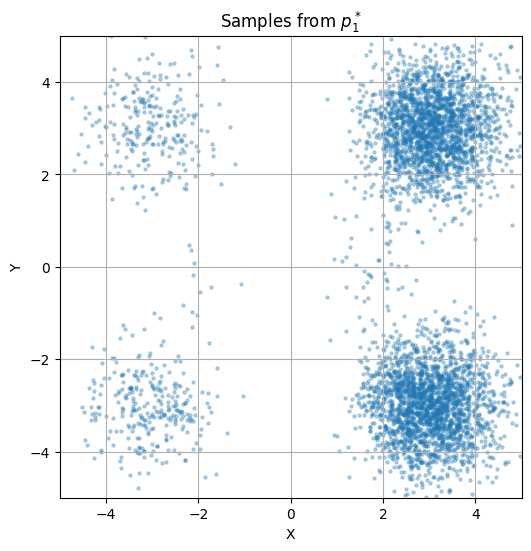

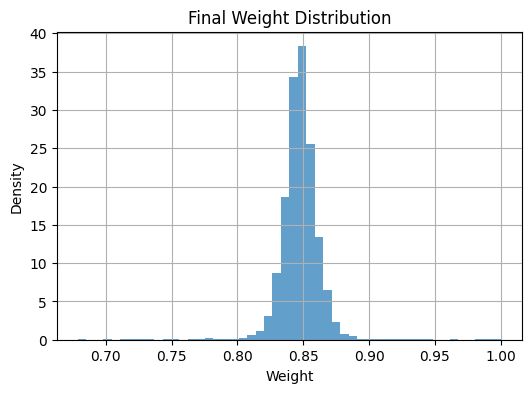

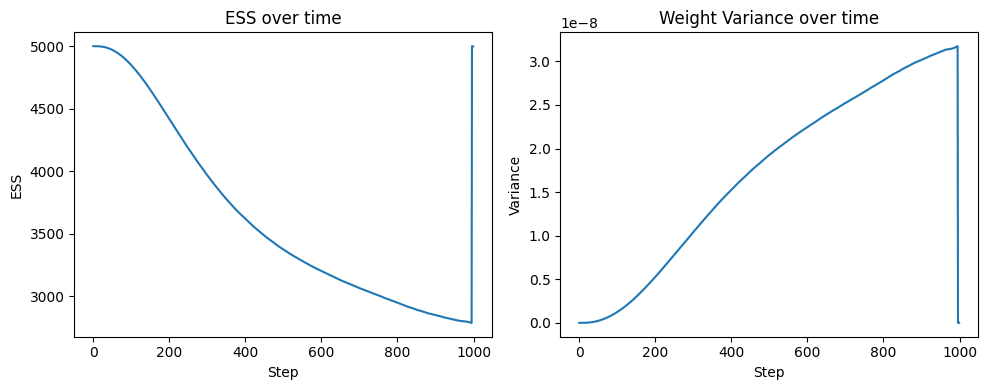

In [15]:
import torch
import math

_eps = 1e-12
_TWOPI = 2.0 * math.pi

# -------------------------
# Time schedules (batch-aware)
# -------------------------
def alpha_fn(t):
    # t: [B,1]
    return 1.0 - t          # [B,1]

def beta_fn(t):
    # t: [B,1]
    return 2.0 / (1.0 - t + 1e-2)  # [B,1]

def sigma_fn(t):
    return torch.sqrt(beta_fn(t))    # [B,1]

# -------------------------
# Stable 1D log-normal
# -------------------------
def _log_normal_1d(x, mu, var):
    # x: [B,1] or [B], mu: [B,K], var: [B,K]
    x = x.reshape(-1, 1)           # [B,1]
    log_pref = -0.5 * torch.log(_TWOPI * var)    # [B,K]
    exp_term = -0.5 * ((x - mu)**2) / var        # [B,K]
    return log_pref + exp_term                    # [B,K]

# -------------------------
# 1D time-dependent score for p(x|A)
# -------------------------
def s1_fn(x, t):
    """
    x: [B,1] or [B], t: [B,1]
    returns: score of same shape as x
    """
    device = x.device
    dtype = x.dtype
    B = x.shape[0]

    # GMM parameters for p(x|A)
    pis = torch.tensor([0.1, 0.9], device=device, dtype=dtype)    # [K]
    mus0 = torch.tensor([-3.0, 3.0], device=device, dtype=dtype) # [K]
    sig2_0 = torch.tensor([0.5**2, 0.5**2], device=device, dtype=dtype) # [K]

    K = pis.shape[0]

    # schedule
    alpha = alpha_fn(t)                  # [B,1]
    s2 = 1.0 - alpha**2                  # [B,1]

    # batch-aware component params: mu_t [B,K], tau2 [B,K]
    mu_t = alpha * mus0.reshape(1,K)     # [B,K]
    tau2 = alpha**2 * sig2_0.reshape(1,K) + s2  # [B,K]

    # log components [B,K]
    x_in = x.reshape(B,1)                # [B,1]
    log_comp = torch.log(pis.reshape(1,K)) + _log_normal_1d(x_in, mu_t, tau2)  # [B,K]

    # responsibilities
    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    r = torch.exp(log_comp - logp)                           # [B,K]

    # component scores
    comp_scores = (mu_t - x_in) / (tau2 + _eps)  # [B,K]
    score = (r * comp_scores).sum(dim=1, keepdim=True)  # [B,1]

    if x.ndim == 2 and x.shape[1] == 1:
        return score
    else:
        return score.reshape(-1)  # [B]

# -------------------------
# 1D time-dependent score for p_X (1D marginal)
# -------------------------
def s2_fn(x, t):
    """
    x: [B,1] or [B], t: [B,1]
    returns: score [B,1]
    """
    device = x.device
    dtype = x.dtype
    B = x.shape[0]

    pis = torch.tensor([0.4,0.2,0.4], device=device, dtype=dtype)  # [K]
    mus0 = torch.tensor([-3.0,0.0,3.0], device=device, dtype=dtype)
    sig2_0 = torch.tensor([0.5**2]*3, device=device, dtype=dtype)

    K = pis.shape[0]

    alpha = alpha_fn(t)                 # [B,1]
    s2 = 1.0 - alpha**2                 # [B,1]

    mu_t = alpha * mus0.reshape(1,K)          # [B,K]
    tau2 = alpha**2 * sig2_0.reshape(1,K) + s2  # [B,K]

    x_in = x.reshape(B,1)                   # [B,1]
    log_comp = torch.log(pis.reshape(1,K)) + _log_normal_1d(x_in, mu_t, tau2)  # [B,K]

    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    r = torch.exp(log_comp - logp)                           # [B,K]

    comp_scores = (mu_t - x_in) / (tau2 + _eps)  # [B,K]
    score = (r * comp_scores).sum(dim=1, keepdim=True)  # [B,1]

    if x.ndim == 2 and x.shape[1] == 1:
        return score
    else:
        return score.reshape(-1)
    
    
# -------------------------
# Stable isotropic multivariate log-normal
# -------------------------
def _log_normal_isotropic(x, mus, tau2):
    # x: [B,D], mus: [B,K,D], tau2: [B,K]
    diff2 = ((x.unsqueeze(1) - mus)**2).sum(-1)   # [B,K]
    D = x.shape[1]
    log_pref = -0.5 * D * torch.log(_TWOPI * tau2)   # [B,K]
    exp_term = -0.5 * diff2 / tau2                    # [B,K]
    return log_pref + exp_term                        # [B,K]

# -------------------------
# 2D time-dependent score for p_X (2D GMM)
# -------------------------
def s3_fn(x, t):
    """
    x: [B,2], t: [B,1]
    returns: score [B,2]
    """
    device = x.device
    dtype = x.dtype
    B = x.shape[0]
    K = 5

    pis = torch.ones(K, device=device, dtype=dtype) / K     # [K]
    mus0 = torch.tensor([[0.,0.],[3.,3.],[-3.,-3.],[3.,-3.],[-3.,3.]], device=device, dtype=dtype)  # [K,2]
    sig2_0 = torch.tensor([0.5]*K, device=device, dtype=dtype)  # [K]

    # schedule
    alpha = alpha_fn(t)                 # [B,1]
    s2 = 1.0 - alpha**2                 # [B,1]

    # batch-aware component params: mu_t [B,K,2], tau2 [B,K]
    mu_t = alpha.unsqueeze(1) * mus0.unsqueeze(0)   # [B,K,2]
    tau2 = alpha**2 * sig2_0.reshape(1,K) + s2      # [B,K]

    # log component densities [B,K]
    x_exp = x.unsqueeze(1)             # [B,1,2]
    log_comp = torch.log(pis.reshape(1,K)) + _log_normal_isotropic(x, mu_t, tau2)  # [B,K]

    # responsibilities
    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    r = torch.exp(log_comp - logp)                           # [B,K]

    # component scores [B,K,2]
    comp_scores = (mu_t - x_exp) / (tau2.unsqueeze(-1) + _eps)  # [B,K,2]
    score = (r.unsqueeze(-1) * comp_scores).sum(dim=1)          # [B,2]
    return score



# -------------------------
# 1D drift for p(x|A)
# -------------------------
def v1_fn(x, t):
    """
    x: [B,1]
    t: [B,1]
    returns: drift [B,1] (same shape as x)
    """
    beta_t = beta_fn(1 - t)           # [B,1]
    score = s1_fn(x, 1 - t)           # [B,1]
    drift = 0.5 * beta_t * x + 0.5 * beta_t * score   # [B,1], broadcasting works
    return drift

# -------------------------
# 2D drift for p_X (2D GMM)
# -------------------------
def v2_fn(x, t):
    """
    x: [B,1]
    t: [B,1]
    returns: drift [B,1]
    """
    beta_t = beta_fn(1 - t)           # [B,1]
    score = s2_fn(x, 1 - t)           # [B,2]
    drift = 0.5 * beta_t * x + 0.5 * beta_t * score  # [B,2], broadcasting works
    return drift

# -------------------------
# 1D drift for p_X (1D marginal)
# -------------------------
def v3_fn(x, t):
    """
    x: [B,2]
    t: [B,1]
    returns: drift [B,2]
    """
    beta_t = beta_fn(1 - t)           # [B,1]
    score = s3_fn(x, 1 - t)           # [B,1]
    drift = 0.5 * beta_t * x + 0.5 * beta_t * score  # [B,1]
    return drift

bs = 5000
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t)         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], 1-t), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], 1-t),                                                 # s2(X)
        lambda x, t: s3_fn(x, 1-t)         # s3(Z|B)
    ],
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    #lambda z, t: torch.cat([v1_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

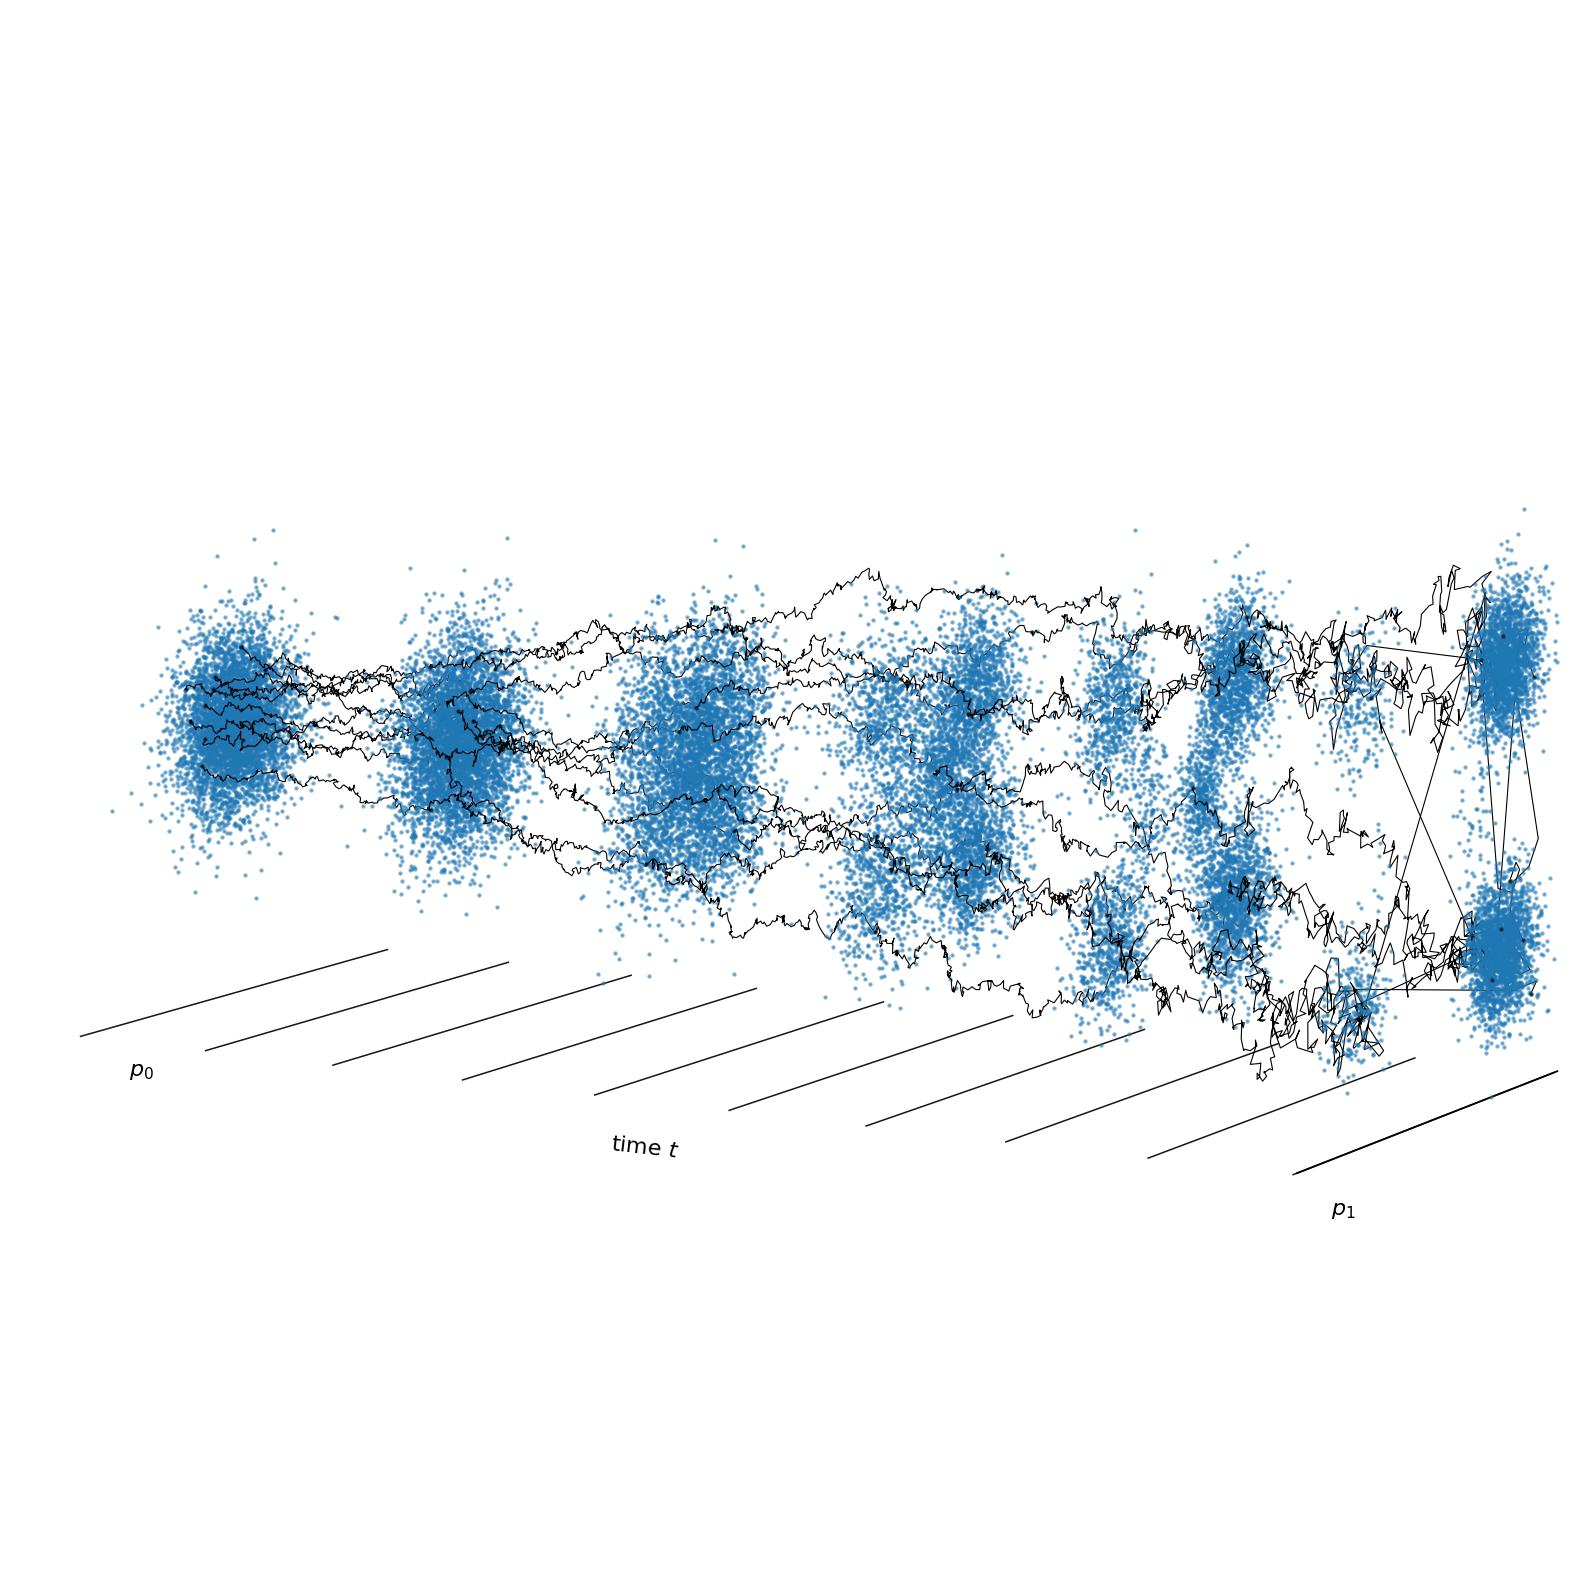

In [18]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name="2D_GMM_path", num_trajectory_points=10)